# Week 3 — Score of a Gaussian: Code Verification

**Companion to**: `notes/w03_score_of_gaussian.md`

## Goals

1. Implement the analytic score function $s(x) = \frac{\mu - x}{\sigma^2}$
2. Verify it matches a numerical (finite-difference) approximation
3. Visualize the score as arrows pointing toward the mean

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---

## Section 1: Implement the Score Function

From your derivation:

$$s(x) = \frac{\mu - x}{\sigma^2} = -\frac{x - \mu}{\sigma^2}$$

### Checkpoint 1.1: Gaussian PDF

In [2]:
def gaussian_pdf(x, mu, sigma):
    """Gaussian probability density function."""
    # Gaussian density: p(x) = (1 / (sigma * sqrt(2*pi))) * exp(-(x-mu)^2 / (2*sigma^2))
    p = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma ** 2))
    return p

### Checkpoint 1.2: Analytic Score

In [3]:
def analytic_score(x, mu, sigma):
    """Analytic score function: s(x) = (mu - x) / sigma^2"""
    # Derived score formula.
    score = (mu - x) / (sigma ** 2)
    return score

### Checkpoint 1.3: Numerical Score (Finite Difference)

The score is $s(x) = \frac{d}{dx} \log p(x)$. We can approximate this numerically:

$$s(x) \approx \frac{\log p(x + \epsilon) - \log p(x - \epsilon)}{2\epsilon}$$

In [4]:
def numerical_score(x, mu, sigma, eps=1e-5):
    """Finite-difference approximation of the score."""
    # Central difference approximation of d/dx log p(x).
    p_plus = gaussian_pdf(x=x+eps, mu=mu, sigma=sigma)
    p_minus = gaussian_pdf(x=x-eps, mu=mu, sigma=sigma)

    logp_plus = np.log(p_plus)
    logp_minus = np.log(p_minus)
    score_den = 2 * eps
    return (logp_plus - logp_minus) / score_den

---

## Section 2: Verify Analytic vs Numerical

In [5]:
# Test parameters
mu = 2.0
sigma = 1.5
x_test = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

# Compare analytic and numerical scores across the test grid.
analytical_vals = analytic_score(x=x_test, mu=mu, sigma=sigma)
numerical_vals = numerical_score(x=x_test, mu=mu, sigma=sigma)
error = np.abs(analytical_vals - numerical_vals)
max_error = np.max(error)
print(f"Max absolute error: {max_error:.2e}")

Max absolute error: 1.29e-10


In [6]:
# ═══════════════════════════════════════════════════════════════
# CHECKPOINT: Verify analytic matches numerical
# ═══════════════════════════════════════════════════════════════
mu, sigma = 2.0, 1.5
x_test = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)

errors = []
for x in x_test:
    analytic = analytic_score(x, mu, sigma)
    numerical = numerical_score(x, mu, sigma)
    errors.append(abs(analytic - numerical))

max_error = max(errors)
assert max_error < 1e-8, f"Max error {max_error:.2e} exceeds threshold"
print(f"✓ Checkpoint passed: max error = {max_error:.2e} < 1e-8")

✓ Checkpoint passed: max error = 1.29e-10 < 1e-8


---

## Section 3: Visualize Score as Arrows

The score tells us which direction to move to increase probability. Let's visualize this with arrows on top of the PDF.

### Checkpoint 3.1: PDF with Score Arrows

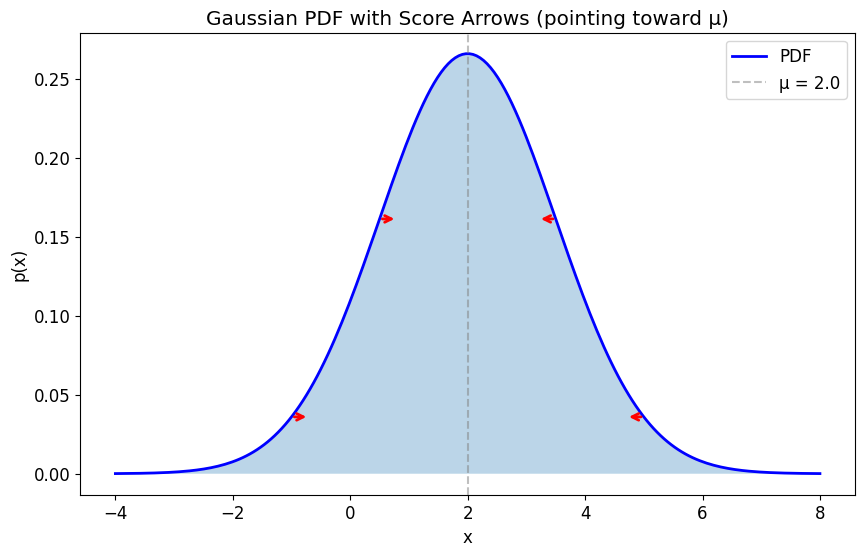

In [7]:
mu = 2.0
sigma = 1.5

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Plot PDF
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
ax.plot(x, pdf, 'b-', linewidth=2, label='PDF')
ax.fill_between(x, pdf, alpha=0.3)

# Add arrows showing score direction at selected x values.
x_arrows = [mu - 2*sigma, mu - sigma, mu, mu + sigma, mu + 2*sigma]
for x_val in x_arrows:
    score = analytic_score(x_val, mu, sigma)
    y_val = stats.norm.pdf(x_val, loc=mu, scale=sigma)
    # Scale arrow length for visibility
    arrow_scale = 0.3
    ax.annotate('', 
                xy=(x_val + arrow_scale * np.sign(score), y_val),
                xytext=(x_val, y_val),
                arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax.axvline(x=mu, color='gray', linestyle='--', alpha=0.5, label=f'μ = {mu}')
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('Gaussian PDF with Score Arrows (pointing toward μ)')
ax.legend()
plt.show()

### What You Should See

- Arrows point **left** when $x > \mu$ (score is negative)
- Arrows point **right** when $x < \mu$ (score is positive)
- **No arrow** at $x = \mu$ (score is zero)

---

## Section 4: Bonus — Score Magnitude vs Position

Plot the score function itself to see how it varies with $x$.

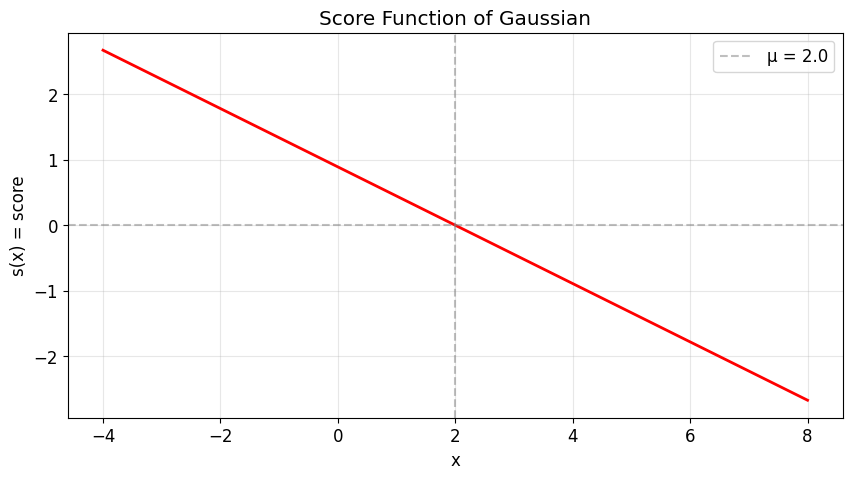

In [8]:
# Plot score as a function of x.
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
scores = [analytic_score(xi, mu, sigma) for xi in x]

plt.figure(figsize=(10, 5))
plt.plot(x, scores, 'r-', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=mu, color='gray', linestyle='--', alpha=0.5, label=f'μ = {mu}')
plt.xlabel('x')
plt.ylabel('s(x) = score')
plt.title('Score Function of Gaussian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observation

The score is a **linear function** of $x$:
- Slope: $-1/\sigma^2$
- Zero crossing: at $x = \mu$

Farther from the mean → stronger "pull" back toward it.

---

## Done!

You have:
1. ✅ Implemented the analytic score from your derivation
2. ✅ Verified it numerically
3. ✅ Visualized how the score points toward the mean

**Next**: See `notes/w03_score_of_gaussian.md` Section 6 for how this connects to diffusion models.